In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [33]:
df = pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [34]:
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nTarget Distribution:")
print(df['Outcome'].value_counts())

Dataset Shape: (768, 9)

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 

In [35]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 614
Testing set size: 154


In [37]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler")
print("Mean of scaled training data:", X_train_scaled.mean(axis=0))
print("Std of scaled training data:", X_train_scaled.std(axis=0))

Features scaled using StandardScaler
Mean of scaled training data: [-6.94341436e-17  1.73585359e-16 -2.09748975e-16 -3.47170718e-17
 -1.59119912e-17  1.35975198e-16 -1.09937394e-16 -1.08490849e-16]
Std of scaled training data: [1. 1. 1. 1. 1. 1. 1. 1.]


In [38]:
baseline_model = LogisticRegression(penalty=None, max_iter=1000, random_state=42)
baseline_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` p

In [39]:
y_pred_baseline = baseline_model.predict(X_test_scaled)

In [40]:
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
print("="*50)
print("BASELINE MODEL (No Regularization)")
print("="*50)
print(f"Accuracy: {baseline_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))
print("\nCoefficients:")
print(baseline_model.coef_)

BASELINE MODEL (No Regularization)
Accuracy: 0.7143

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154


Coefficients:
[[ 0.38069548  1.16644131 -0.20472194  0.0696351  -0.1371041   0.72747363
   0.25934003  0.18192122]]


In [41]:
l2_model = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42)
l2_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` p

In [42]:
y_pred_l2 = l2_model.predict(X_test_scaled)

In [43]:
l2_accuracy = accuracy_score(y_test, y_pred_l2)
print("="*50)
print("L2 REGULARIZATION (Ridge)")
print("="*50)
print(f"Accuracy: {l2_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_l2))
print("\nCoefficients:")
print(l2_model.coef_)

L2 REGULARIZATION (Ridge)
Accuracy: 0.7143

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154


Coefficients:
[[ 0.37317821  1.14415127 -0.19763683  0.06653497 -0.12730823  0.71389341
   0.25552675  0.18417899]]


In [44]:
l1_model = LogisticRegression(penalty='l1', C=1.0, solver='liblinear', 
                               max_iter=1000, random_state=42)
l1_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` p

In [45]:
y_pred_l1 = l1_model.predict(X_test_scaled)

In [46]:
l1_accuracy = accuracy_score(y_test, y_pred_l1)
print("="*50)
print("L1 REGULARIZATION (Lasso)")
print("="*50)
print(f"Accuracy: {l1_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_l1))
print("\nCoefficients:")
print(l1_model.coef_)
print("\nNumber of zero coefficients:", np.sum(l1_model.coef_ == 0))

L1 REGULARIZATION (Lasso)
Accuracy: 0.7143

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154


Coefficients:
[[ 0.36603675  1.13562451 -0.18251508  0.04498285 -0.10764997  0.70651368
   0.24651278  0.17358262]]

Number of zero coefficients: 0


In [47]:
elastic_model = LogisticRegression(penalty='elasticnet', C=1.0, l1_ratio=0.5,
                                   solver='saga', max_iter=1000, random_state=42)
elastic_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'elasticnet'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.5
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [48]:
y_pred_elastic = elastic_model.predict(X_test_scaled)

In [49]:
elastic_accuracy = accuracy_score(y_test, y_pred_elastic)
print("="*50)
print("ELASTIC NET REGULARIZATION")
print("="*50)
print(f"Accuracy: {elastic_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_elastic))
print("\nCoefficients:")
print(elastic_model.coef_)
print("\nNumber of zero coefficients:", np.sum(elastic_model.coef_ == 0)) 

ELASTIC NET REGULARIZATION
Accuracy: 0.7143

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154


Coefficients:
[[ 0.36992468  1.1409986  -0.19046617  0.05583421 -0.11765931  0.71159954
   0.25104343  0.17942157]]

Number of zero coefficients: 0


In [50]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
results = {'C': [], 'L1_Accuracy': [], 'L2_Accuracy': [], 'Elastic_Accuracy': []}

In [51]:
for C in C_values:
    # L1
    model_l1 = LogisticRegression(penalty='l1', C=C, solver='liblinear', 
                                   max_iter=1000, random_state=42)
    model_l1.fit(X_train_scaled, y_train)
    acc_l1 = accuracy_score(y_test, model_l1.predict(X_test_scaled))
    
    # L2
    model_l2 = LogisticRegression(penalty='l2', C=C, max_iter=1000, random_state=42)
    model_l2.fit(X_train_scaled, y_train)
    acc_l2 = accuracy_score(y_test, model_l2.predict(X_test_scaled))
    
    # Elastic Net
    model_elastic = LogisticRegression(penalty='elasticnet', C=C, l1_ratio=0.5,
                                       solver='saga', max_iter=1000, random_state=42)
    model_elastic.fit(X_train_scaled, y_train)
    acc_elastic = accuracy_score(y_test, model_elastic.predict(X_test_scaled))
    
    results['C'].append(C)
    results['L1_Accuracy'].append(acc_l1)
    results['L2_Accuracy'].append(acc_l2)
    results['Elastic_Accuracy'].append(acc_elastic)
    
    print(f"C={C}: L1={acc_l1:.4f}, L2={acc_l2:.4f}, Elastic={acc_elastic:.4f}")


C=0.001: L1=0.6494, L2=0.6558, Elastic=0.6494
C=0.01: L1=0.7078, L2=0.7338, Elastic=0.6883
C=0.1: L1=0.6948, L2=0.7143, Elastic=0.7078
C=1: L1=0.7143, L2=0.7143, Elastic=0.7143
C=10: L1=0.7143, L2=0.7143, Elastic=0.7143
C=100: L1=0.7143, L2=0.7143, Elastic=0.7143


In [52]:
results_df = pd.DataFrame(results)
print("\nResults Summary:")
print(results_df)


Results Summary:
         C  L1_Accuracy  L2_Accuracy  Elastic_Accuracy
0    0.001     0.649351     0.655844          0.649351
1    0.010     0.707792     0.733766          0.688312
2    0.100     0.694805     0.714286          0.707792
3    1.000     0.714286     0.714286          0.714286
4   10.000     0.714286     0.714286          0.714286
5  100.000     0.714286     0.714286          0.714286


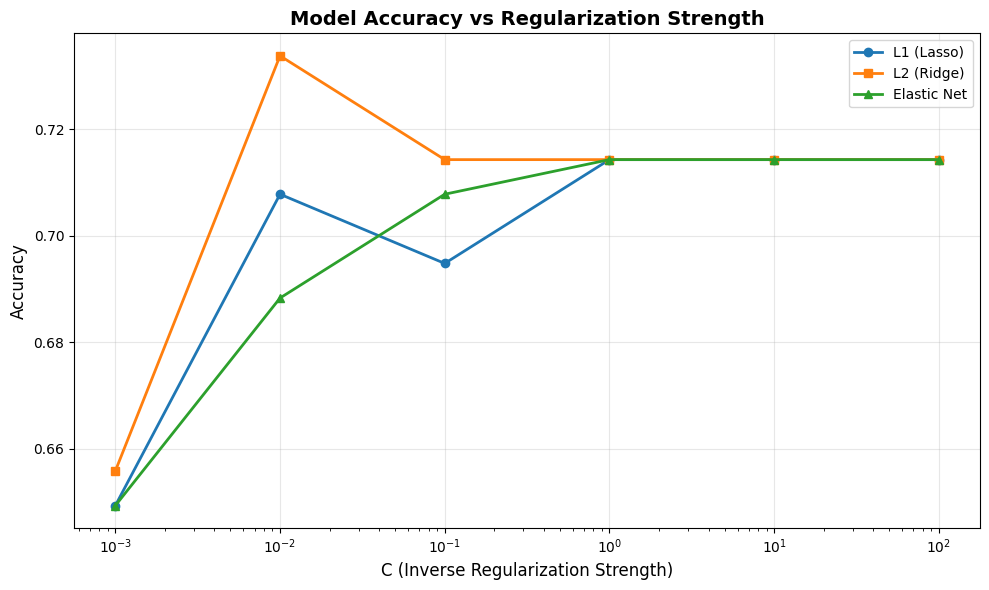

In [53]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['C'], results_df['L1_Accuracy'], marker='o', label='L1 (Lasso)', linewidth=2)
plt.plot(results_df['C'], results_df['L2_Accuracy'], marker='s', label='L2 (Ridge)', linewidth=2)
plt.plot(results_df['C'], results_df['Elastic_Accuracy'], marker='^', label='Elastic Net', linewidth=2)
plt.xscale('log')
plt.xlabel('C (Inverse Regularization Strength)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Accuracy vs Regularization Strength', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [54]:
feature_names = X.columns
coef_comparison = pd.DataFrame({
    'Feature': feature_names,
    'Baseline': baseline_model.coef_[0],
    'L1 (Lasso)': l1_model.coef_[0],
    'L2 (Ridge)': l2_model.coef_[0],
    'Elastic Net': elastic_model.coef_[0]
})

print("\nCoefficient Comparison:")
print(coef_comparison)



Coefficient Comparison:
                    Feature  Baseline  L1 (Lasso)  L2 (Ridge)  Elastic Net
0               Pregnancies  0.380695    0.366037    0.373178     0.369925
1                   Glucose  1.166441    1.135625    1.144151     1.140999
2             BloodPressure -0.204722   -0.182515   -0.197637    -0.190466
3             SkinThickness  0.069635    0.044983    0.066535     0.055834
4                   Insulin -0.137104   -0.107650   -0.127308    -0.117659
5                       BMI  0.727474    0.706514    0.713893     0.711600
6  DiabetesPedigreeFunction  0.259340    0.246513    0.255527     0.251043
7                       Age  0.181921    0.173583    0.184179     0.179422


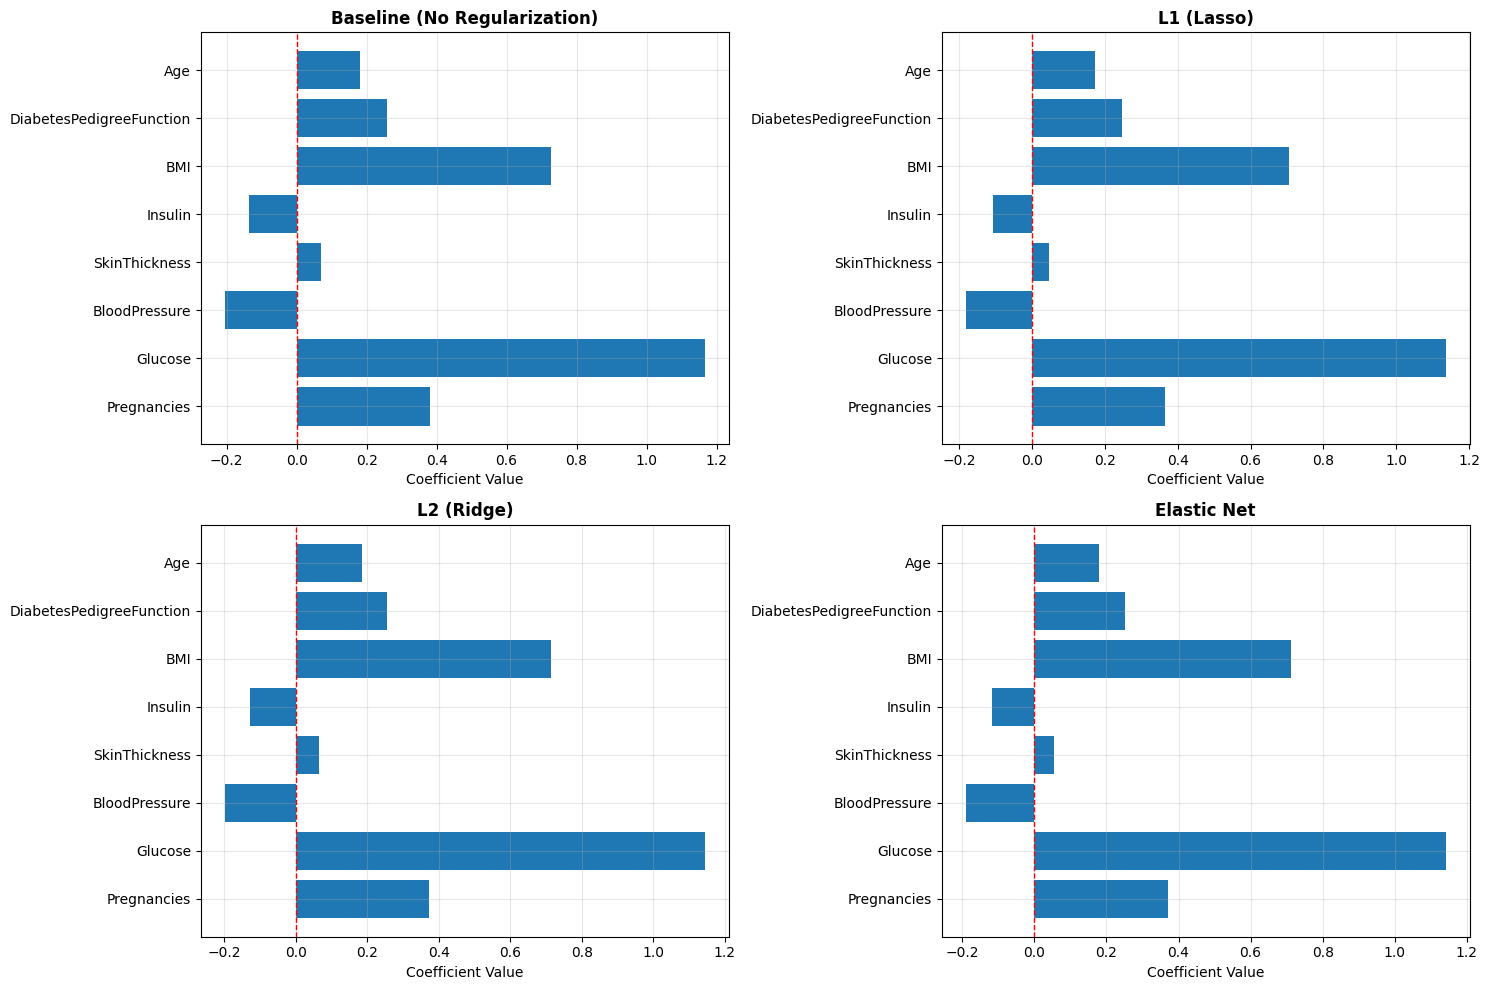

In [55]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
models = [baseline_model, l1_model, l2_model, elastic_model]
titles = ['Baseline (No Regularization)', 'L1 (Lasso)', 'L2 (Ridge)', 'Elastic Net']

for idx, (model, title, ax) in enumerate(zip(models, titles, axes.flat)):
    coefs = model.coef_[0]
    ax.barh(feature_names, coefs)
    ax.set_xlabel('Coefficient Value')
    ax.set_title(title, fontweight='bold')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [56]:
summary = pd.DataFrame({
    'Model': ['Baseline', 'L1 (Lasso)', 'L2 (Ridge)', 'Elastic Net'],
    'Accuracy': [baseline_accuracy, l1_accuracy, l2_accuracy, elastic_accuracy],
    'Non-zero Coefficients': [
        np.sum(baseline_model.coef_[0] != 0),
        np.sum(l1_model.coef_[0] != 0),
        np.sum(l2_model.coef_[0] != 0),
        np.sum(elastic_model.coef_[0] != 0)
    ]
})

In [57]:
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
print(summary.to_string(index=False))
print("\nKey Insights:")
print("- L1 performs feature selection (some coefficients become zero)")
print("- L2 shrinks all coefficients but keeps all features")
print("- Elastic Net combines both L1 and L2 benefits")
print("- Regularization helps prevent overfitting")


FINAL SUMMARY
      Model  Accuracy  Non-zero Coefficients
   Baseline  0.714286                      8
 L1 (Lasso)  0.714286                      8
 L2 (Ridge)  0.714286                      8
Elastic Net  0.714286                      8

Key Insights:
- L1 performs feature selection (some coefficients become zero)
- L2 shrinks all coefficients but keeps all features
- Elastic Net combines both L1 and L2 benefits
- Regularization helps prevent overfitting
